DMRG energy: -0.7187582535544665


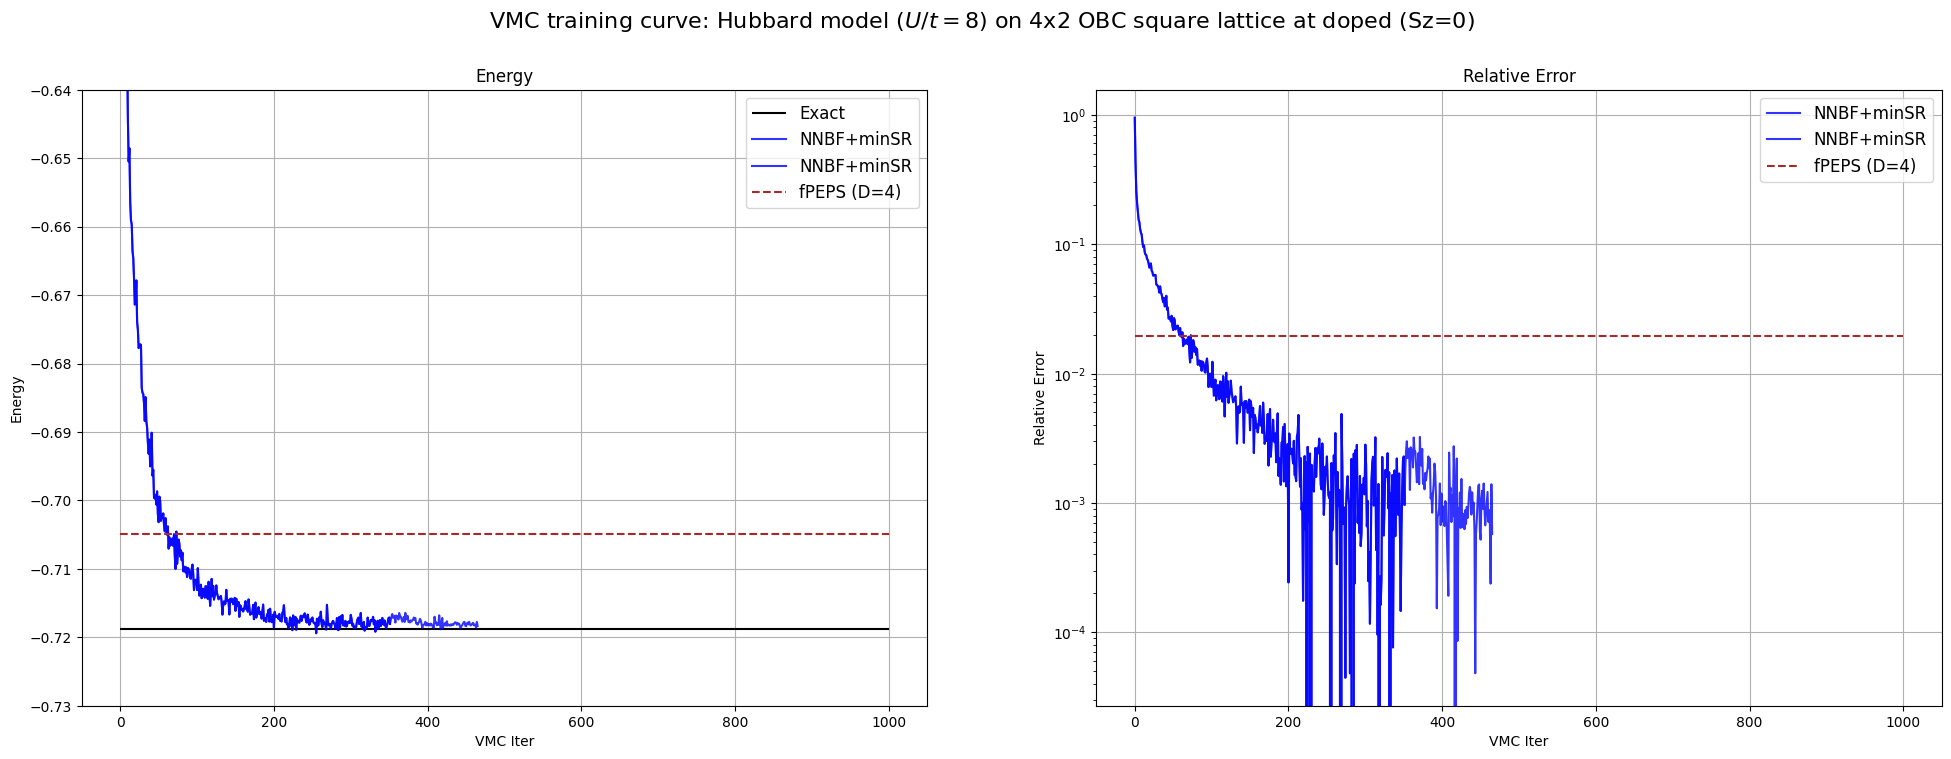

In [103]:
import json
import matplotlib.pyplot as plt
import glob

# Function to read data from JSON file
def read_data_from_json(file_name):
    with open(file_name, 'r') as f:
        data = json.load(f)
    return data
t=1.0
U=8.0
symmetry='Z2'
Lx=4
Ly=2
N=int(Lx*Ly-2)

model_name_list = ['NNBF'
                   'HFDS',]
legend_dict = {
    'fTN':'fPEPS',
    'fTN_backflow': 'fPEPS_backflow', 
    'fTN_backflow_attn': 'fPEPS_backflow_attn', 
    'fTN_backflow_attn-GO': 'fPEPS_backflow_attn-GO',
    'fTN_backflow_attn_Tensorwise_v1': 'fPEPS+NN (Tensorwise)',
    'fTN_backflow_attn_boundary': 'fPEPS_backflow_attn_boundary',
    'NeuralBackflow_spinful': 'NNBF_product',
    'fTN_backflow_attn_Jastrow': 'fPEPS_backflow_attn_Jastrow',
    'fTN_SWO': 'fPEPS_SWO',
    'HFDS': 'HFDS'
    }
color_list = ['blue', 'purple', 'orange', 'brown', 'pink']
color_map = dict(zip(model_name_list, color_list))

symbol_dict = {
    'fTN':'s',
    'fTN_backflow': 's', 
    'fTN_backflow_attn': 'D', 
    'fTN_backflow_attn-GO': 'X',
    'fTN_backflow_attn_boundary': 'h',
    'NeuralBackflow_spinful': 'o',
    'HFDS': 'v'
    }
scale = 1/(Lx*Ly)
# scale = 1

fig, ax = plt.subplots(1, 2, figsize=(24, 8))

dmrg_energy = -0.7187582535544665
ax[0].hlines([dmrg_energy], xmin=0, xmax=1000, color='black', label="Exact")
alpha = 0.8

file_pattern = './sr/minSR/energy_stats_start_*.json'


# Collecting all files that match the pattern
file_list = glob.glob(file_pattern)
# Sort the file list according to the iteration number
file_list.sort(key=lambda x: int(x.split('_')[-1].split('.')[0]))

# Initialize lists to concatenate data
concatenated_means = []
concatenated_errors = []
concatenated_steps = []

for file_name in file_list:  # Sorting files to keep steps in order
    # Read data from the JSON file
    data = read_data_from_json(file_name)
    sample_size = data.get("sample size:", None)

    # Extracting and normalizing means and errors
    means_ftnn_nn = data["mean"]
    means_ftnn_nn = [mean * scale for mean in means_ftnn_nn]  # Normalize the energy
    errors_ftn_nn = data["error"]
    errors_ftn_nn = [error * scale for error in errors_ftn_nn]  # Normalize the error
    steps_ftn_nn = list(range(len(concatenated_means), len(concatenated_means) + len(means_ftnn_nn)))

    # Concatenating data
    concatenated_means.extend(means_ftnn_nn)
    concatenated_errors.extend(errors_ftn_nn)
    concatenated_steps.extend(steps_ftn_nn)
    # Plotting the concatenated data
    ax[0].plot(concatenated_steps, concatenated_means, color='blue', label='NNBF+minSR', alpha=alpha)
    ax[1].plot(concatenated_steps, [(e - dmrg_energy) / abs(dmrg_energy) for e in concatenated_means], color='blue', label='NNBF+minSR', alpha=alpha)

# ax[0].hlines([-0.544355144920918], xmin=0, xmax=1000, color='orange', label="SU D=2", linestyles='--')
ax[0].hlines([-0.7048584959373627], xmin=0, xmax=1000, color='brown', label="fPEPS (D=4)", linestyles='--')
# ax[0].hlines([-0.7174873318604107], xmin=0, xmax=1000, color='purple', label="fPEPS (D=6)", linestyles='--')
ax[0].set_xlabel('VMC Iter')
ax[0].set_ylabel('Energy')
ax[0].legend(loc='upper right', fontsize=12)
ax[0].set_ylim(-0.73, -0.64)
ax[0].set_title(r'Energy')
ax[0].grid(True)

# plt.grid(True)
ax[1].hlines([(-0.7048584959373627-dmrg_energy)/abs(dmrg_energy)], xmin=0, xmax=1000, color='brown', label="fPEPS (D=4)", linestyles='--')
# ax[1].hlines([(-0.7174873318604107-dmrg_energy)/abs(dmrg_energy)], xmin=0, xmax=1000, color='purple', label="fPEPS D=6", linestyles='--')
ax[1].set_xlabel('VMC Iter')
ax[1].set_ylabel('Relative Error')
ax[1].set_yscale('log')
ax[1].legend(loc='upper right', fontsize=12)
ax[1].grid(True)
ax[1].title.set_text(f'Relative Error')
print(f'DMRG energy: {dmrg_energy}')
plt.suptitle(r'VMC training curve: Hubbard model ($U/t=8$) on {}x{} OBC square lattice at doped (Sz=0)'.format(Lx, Ly), fontsize=16)
import os
# os.makedirs(f'./plots/{Lx}x{Ly}/t={t}_U={U}/N={N}', exist_ok=True)
# plt.savefig(f'./plots/{Lx}x{Ly}/t={t}_U={U}/N={N}/{Lx}x{Ly}_N={N}_{symmetry}.png', dpi=300, bbox_inches='tight')
plt.show()